In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import MaterialDataLoader

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Setup complete!")

Setup complete!


In [2]:
loader = MaterialDataLoader(data_dir='../data')

# Load band gap dataset (106,113 materials)
df = loader.load('band_gap')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Loading matbench_mp_gap from Matminer...
Saved to ../data\band_gap.csv
Loaded 106113 samples
Dataset shape: (106113, 2)

Columns: ['structure', 'gap pbe']

First few rows:


,structure,gap pbe
0,"[[-0.00812638 0.02476014 -0.01698117] K, [-0....",1.3322
1,"[[0. 1.78463544 1.78463544] Cr, [1.784...",0.0000
2,"[[-2.13764909 -2.12540569 -2.14704542] Cs, [-6...",0.0000
3,"[[0. 0. 0.] Si, [ 4.55195829 4.55195829 -4.55...",0.4113
4,"[[0. 2.655 2.655] Ca, [2.655 0. 2.655] C...",0.3514


In [3]:
# Target variable statistics
target_col = 'gap pbe'
print(f"Target: {target_col}")
print(f"\n{df[target_col].describe()}")

# Check for missing values
print(f"\nMissing values: {df[target_col].isna().sum()}")
print(f"Zero band gaps (metals): {(df[target_col] == 0).sum()}")
print(f"Non-zero band gaps (semiconductors/insulators): {(df[target_col] > 0).sum()}")

Target: gap pbe

count    106113.000000
mean          1.214627
std           1.598966
min           0.000000
25%           0.000000
50%           0.273800
75%           2.207500
max           9.721200
Name: gap pbe, dtype: float64

Missing values: 0
Zero band gaps (metals): 46151
Non-zero band gaps (semiconductors/insulators): 59962


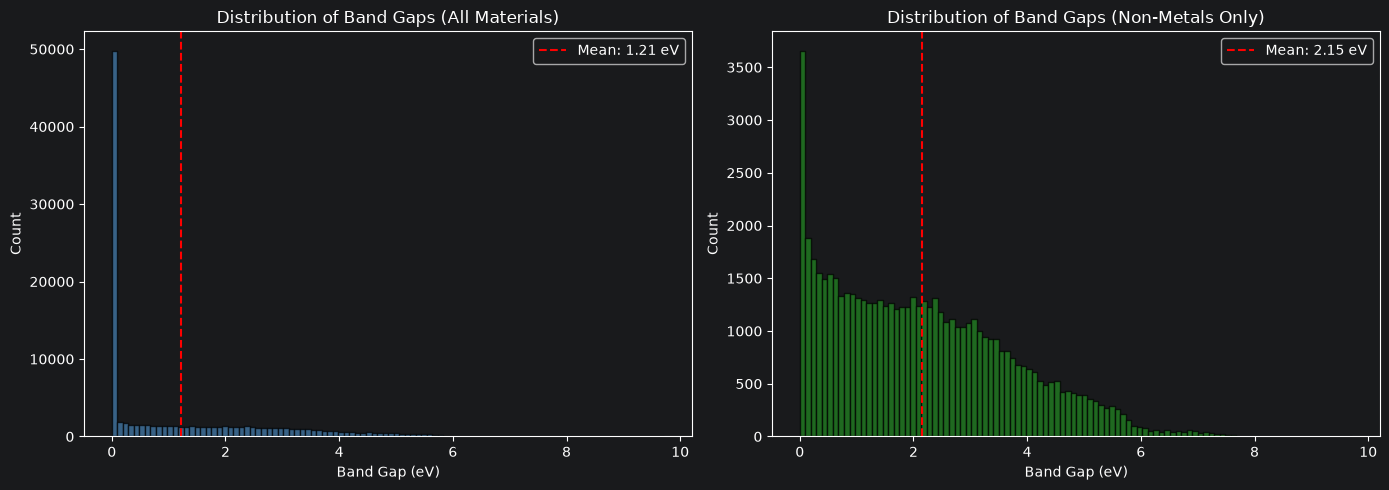

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all band gaps
axes[0].hist(df[target_col], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Band Gap (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Band Gaps (All Materials)')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f"Mean: {df[target_col].mean():.2f} eV")
axes[0].legend()

# Histogram excluding metals (gap > 0)
non_metal = df[df[target_col] > 0][target_col]
axes[1].hist(non_metal, bins=100, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Band Gap (eV)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Band Gaps (Non-Metals Only)')
axes[1].axvline(non_metal.mean(), color='red', linestyle='--', label=f"Mean: {non_metal.mean():.2f} eV")
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/bandgap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

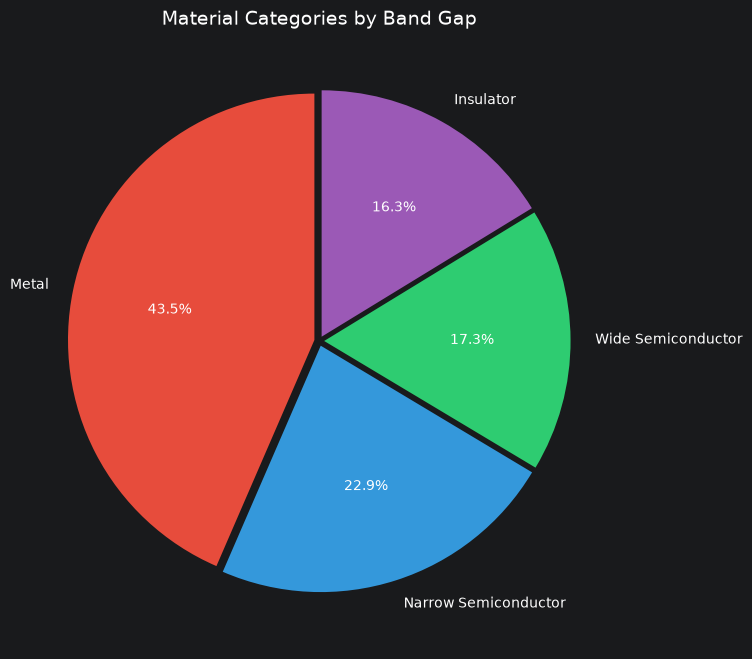

category
Metal                   46151
Narrow Semiconductor    24316
Wide Semiconductor      18385
Insulator               17261
Name: count, dtype: int64


In [5]:
# Categorize materials
def categorize_band_gap(gap):
    if gap == 0:
        return 'Metal'
    elif gap < 1.5:
        return 'Narrow Semiconductor'
    elif gap < 3.0:
        return 'Wide Semiconductor'
    else:
        return 'Insulator'

df['category'] = df[target_col].apply(categorize_band_gap)

# Plot pie chart
category_counts = df['category'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.02]*len(category_counts))
plt.title('Material Categories by Band Gap', fontsize=14)
plt.savefig('../results/material_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print(category_counts)

In [6]:
# Load multiple datasets for comparison
datasets = ['steels', 'band_gap']
dataset_info = []

for name in datasets:
    try:
        d = loader.load(name)
        target_cols = [c for c in d.columns if c in ['gap pbe', 'e_form', 'log10(K_VRH)',
                                                     'log10(G_VRH)', 'is_metal', 'yield strength', 'tensile strength']]
        dataset_info.append({
            'Dataset': name,
            'Samples': len(d),
            'Target': target_cols[0] if target_cols else 'N/A',
            'Target Mean': d[target_cols[0]].mean() if target_cols else 'N/A',
            'Columns': len(d.columns)
        })
    except Exception as e:
        print(f"Error loading {name}: {e}")

info_df = pd.DataFrame(dataset_info)
info_df

Loading matbench_steels from Matminer...
Saved to ../data\steels.csv
Loaded 312 samples
Loading matbench_mp_gap from Matminer...
Saved to ../data\band_gap.csv
Loaded 106113 samples


,Dataset,Samples,Target,Target Mean,Columns
0,steels,312,yield strength,1420.998397,2
1,band_gap,106113,gap pbe,1.214627,2


In [7]:
# Load trained model results
import json
import os

results_dir = '../results'

# Check what results exist
if os.path.exists(results_dir):
    files = os.listdir(results_dir)
    print("Results files:")
    for f in sorted(files):
        print(f"  {f}")
else:
    print("No results directory found. Run train.py first!")

Results files:
  bandgap_distribution.png
  material_categories.png


Parity Plot (Predicted vs Actual):


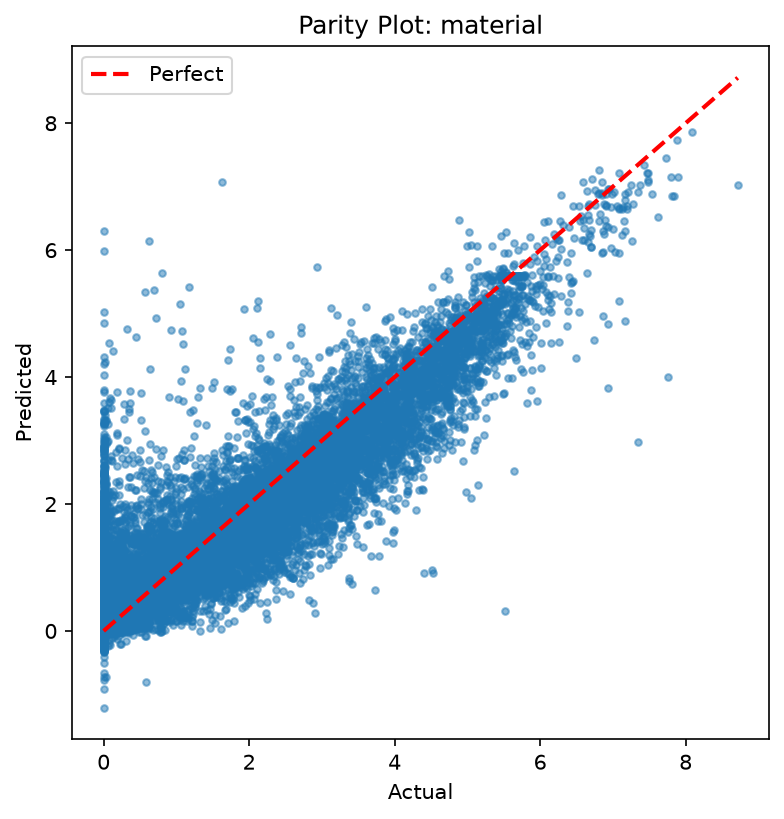


Feature Importance:


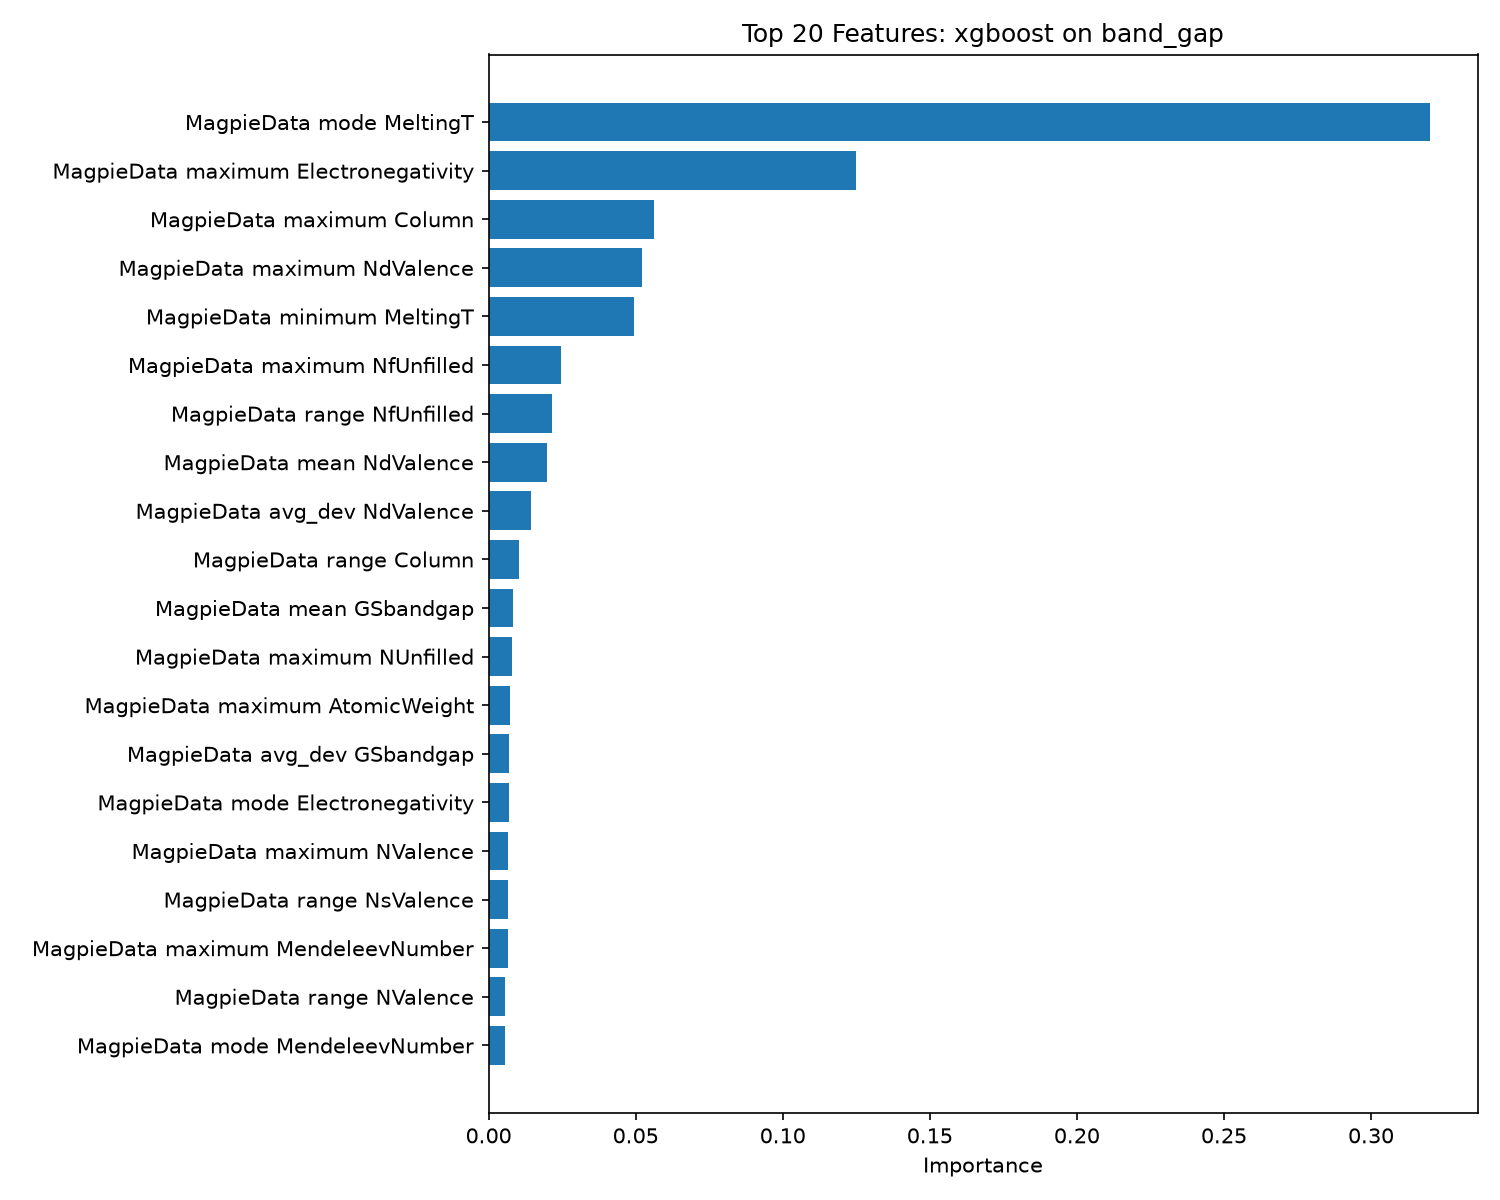

In [19]:
from IPython.display import Image, display

# Display parity plot if it exists
parity_path = '../src/results/parity_plot.png'
if os.path.exists(parity_path):
    print("Parity Plot (Predicted vs Actual):")
    display(Image(filename=parity_path))
else:
    print("Parity plot not found. Run train.py first!")

# Display feature importance if it exists
importance_path = '../src/results/feature_importance.png'
if os.path.exists(importance_path):
    print("\nFeature Importance:")
    display(Image(filename=importance_path))
else:
    print("Feature importance plot not found.")

In [23]:
metrics_path = '../src/results/metrics.json '
if os.path.exists(metrics_path):
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    print("Training Metrics:")
    print("="*40)
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key:20s}: {value:.4f}")
        else:
            print(f"{key:20s}: {value}")
else:
    print("Metrics file not found. Run train.py first!")

Training Metrics:
train_mae           : 0.3108
test_mae            : 0.3766
train_rmse          : 0.4928
test_rmse           : 0.6191
train_r2            : 0.9051
test_r2             : 0.8499
